In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset into a DataFrame
df = pd.read_csv('bank.csv')
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,35.0,NaN,married,primary,no,102.0,yes,no,unknown,20,may,1334.0,1,-1.0,0,unknown,yes
1,49.0,blue-collar,married,secondary,no,2039.0,yes,no,cellular,6,may,451.0,1,169.0,2,failure,yes
2,57.0,NaN,married,secondary,no,3754.0,no,no,cellular,5,feb,1063.0,2,-1.0,0,unknown,yes
3,31.0,unknown,married,tertiary,no,526.0,no,no,cellular,26,aug,130.0,13,-1.0,0,unknown,no
4,42.0,unemployed,married,secondary,no,356.0,yes,no,cellular,7,may,787.0,3,356.0,2,failure,yes


Exploratory Data Analysis

In [4]:
# Print the total number of rows and columns in the dataset
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (11720, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [5]:
print(df.dtypes)

age          float64
job           object
marital       object
education     object
default       object
balance      float64
housing       object
loan          object
contact       object
day            int64
month         object
duration     float64
campaign       int64
pdays        float64
previous       int64
poutcome      object
deposit       object
dtype: object


In [6]:
# Get statistical summary of numerical columns
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10782.000000,10784.000000,11720.000000,10792.000000,11720.000000,10793.000000,11720.000000
mean,41.286311,1549.425445,15.677560,372.230170,2.502645,51.958306,0.832509
std,11.959782,3290.033093,8.421933,347.655864,2.712524,109.479698,2.280265
min,18.000000,-3058.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,127.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,551.500000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1696.000000,22.000000,494.000000,3.000000,41.000000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [7]:
# Count missing values in each column
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Show as a clean table
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0])

           Missing Count  Percentage
age                  938    8.003413
job                 1450   12.372014
education            942    8.037543
balance              936    7.986348
contact              947    8.080205
duration             928    7.918089
pdays                927    7.909556
poutcome             951    8.114334


In [8]:
# See how balanced our target variable is
print(df['deposit'].value_counts())
print()
print(df['deposit'].value_counts(normalize=True) * 100)

deposit
no     6163
yes    5557
Name: count, dtype: int64

deposit
no     52.585324
yes    47.414676
Name: proportion, dtype: float64


Data Cleaning and Imputation

In [9]:
# Fill missing numerical columns with median
df['age'] = df['age'].fillna(df['age'].median())
df['balance'] = df['balance'].fillna(df['balance'].median())
df['duration'] = df['duration'].fillna(df['duration'].median())
df['pdays'] = df['pdays'].fillna(-1)  # -1 means client was never contacted before

# Confirm no more missing in these columns
print(df[['age', 'balance', 'duration', 'pdays']].isnull().sum())

age         0
balance     0
duration    0
pdays       0
dtype: int64


In [10]:
# Fill missing categorical columns with mode (most frequent value)
df['job'] = df['job'].fillna(df['job'].mode()[0])
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['contact'] = df['contact'].fillna(df['contact'].mode()[0])
df['poutcome'] = df['poutcome'].fillna(df['poutcome'].mode()[0])

# Confirm no more missing in these columns
print(df[['job', 'education', 'contact', 'poutcome']].isnull().sum())

job          0
education    0
contact      0
poutcome     0
dtype: int64


In [11]:
# Final check - should show all zeros
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


Feature Engineering and Outlier Capping

In [12]:
# Using IQR method to cap outliers in balance, duration, campaign
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)
    return df

# Apply to numerical columns that may have outliers
for col in ['balance', 'duration', 'campaign', 'pdays', 'previous']:
    df = cap_outliers(df, col)

print("Outliers handled successfully!")

Outliers handled successfully!


In [13]:
# Convert target column 'deposit' from yes/no to 1/0
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

print(df['deposit'].value_counts())

deposit
0    6163
1    5557
Name: count, dtype: int64


Data Visualization

In [14]:
# Set color blind friendly palette for all plots
sns.set_theme(style="whitegrid")
palette = sns.color_palette("colorblind")

C:\Users\acer\AppData\Local\Temp\ipykernel_10964\1456087563.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='deposit', data=df, palette='colorblind')


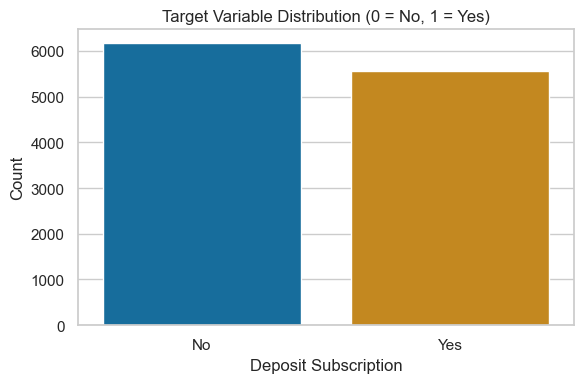

In [15]:
#VISUALIZATION 1: Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='deposit', data=df, palette='colorblind')
plt.title('Target Variable Distribution (0 = No, 1 = Yes)')
plt.xlabel('Deposit Subscription')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

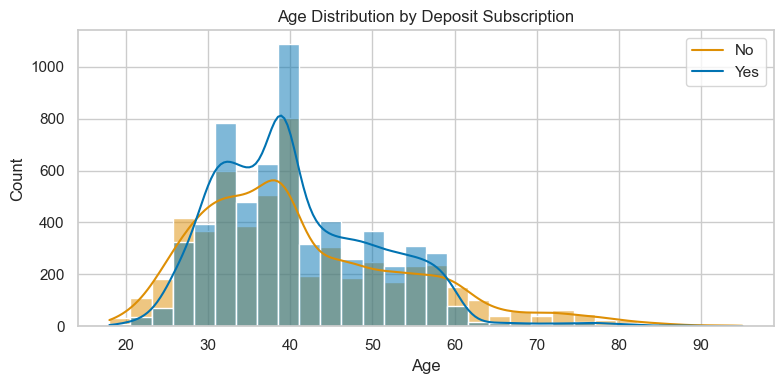

In [16]:
# VISUALIZATION 2: Age Distribution by Deposit Subscription
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='deposit', kde=True, palette='colorblind', bins=30)
plt.title('Age Distribution by Deposit Subscription')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_10964\945966625.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='deposit', y='balance', data=df, palette='colorblind')


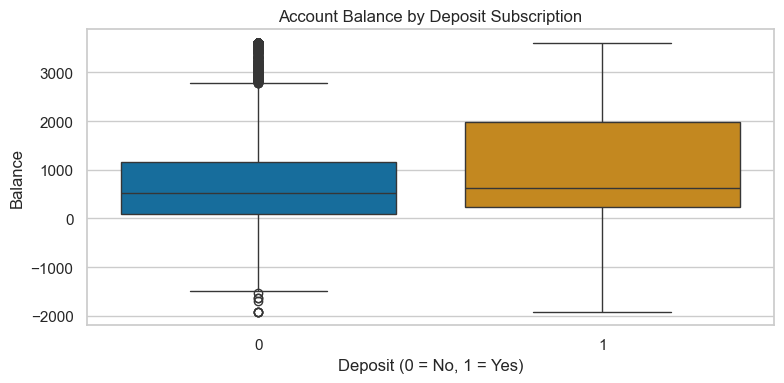

In [17]:
# VISUALIZATION 3: Account Balance by Deposit Subscription
plt.figure(figsize=(8, 4))
sns.boxplot(x='deposit', y='balance', data=df, palette='colorblind')
plt.title('Account Balance by Deposit Subscription')
plt.xlabel('Deposit (0 = No, 1 = Yes)')
plt.ylabel('Balance')
plt.tight_layout()
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_10964\476695334.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_deposit.index, y=job_deposit.values, palette='colorblind')


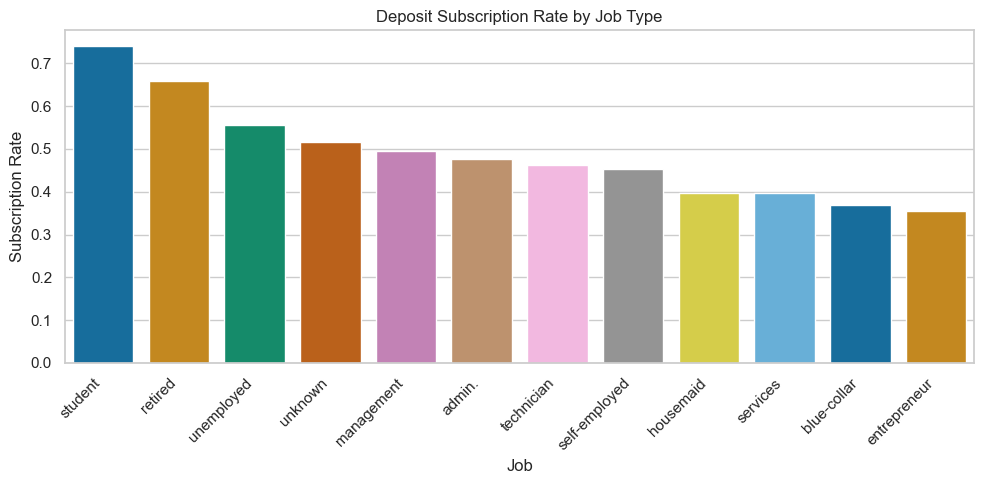

In [18]:
# VISUALIZATION 4: Subscription Rate by Job Type
plt.figure(figsize=(10, 5))
job_deposit = df.groupby('job')['deposit'].mean().sort_values(ascending=False)
sns.barplot(x=job_deposit.index, y=job_deposit.values, palette='colorblind')
plt.title('Deposit Subscription Rate by Job Type')
plt.xlabel('Job')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_10964\1496778639.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_deposit.index, y=edu_deposit.values, palette='colorblind')


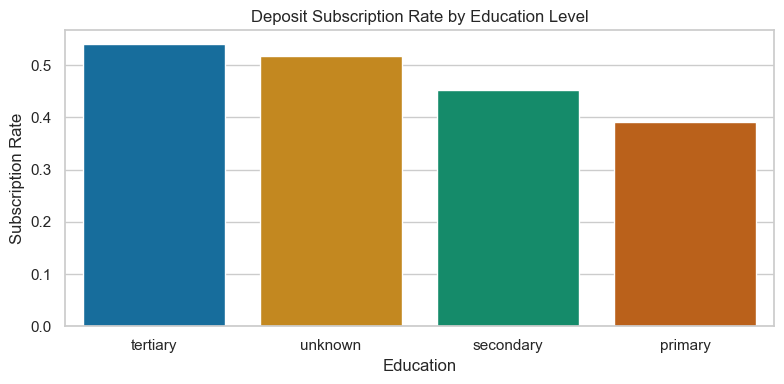

In [19]:
# VISUALIZATION 5: Subscription Rate by Education Level
plt.figure(figsize=(8, 4))
edu_deposit = df.groupby('education')['deposit'].mean().sort_values(ascending=False)
sns.barplot(x=edu_deposit.index, y=edu_deposit.values, palette='colorblind')
plt.title('Deposit Subscription Rate by Education Level')
plt.xlabel('Education')
plt.ylabel('Subscription Rate')
plt.tight_layout()
plt.show()

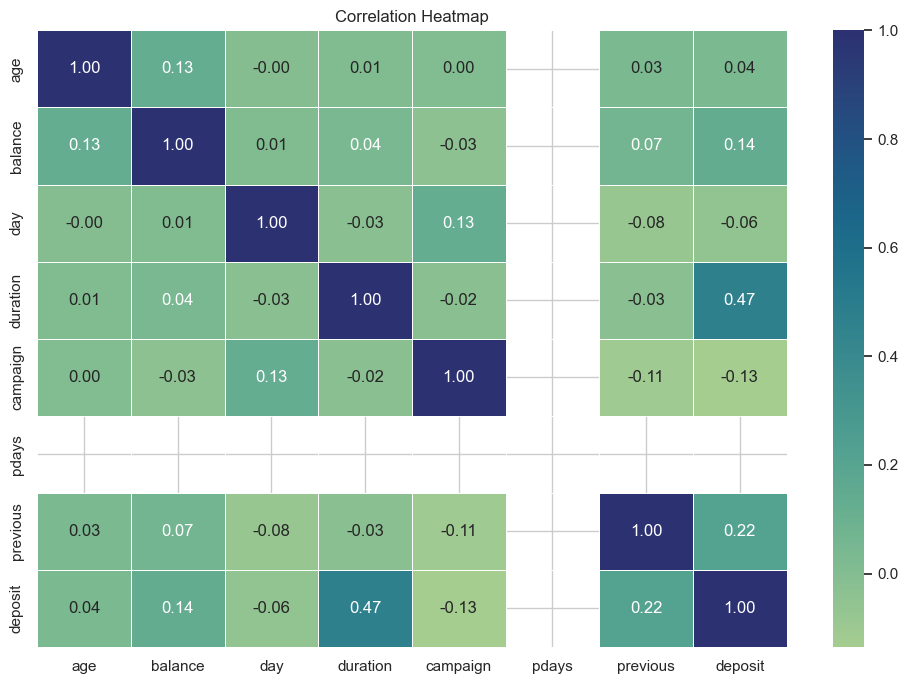

In [20]:
# VISUALIZATION 6: Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', 
            cmap='crest', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [21]:
# Label Encoding for binary columns and One-Hot Encoding for multi-class columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Binary categorical columns - label encode
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Multi-class categorical columns - one-hot encode
multi_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print(df.head())

Shape after encoding: (11720, 43)
    age  default  balance  housing  loan  day  duration  campaign  pdays  \
0  35.0        0    102.0        1     0   20     932.0         1   -1.0   
1  49.0        0   2039.0        1     0    6     451.0         1   -1.0   
2  57.0        0   3609.0        0     0    5     932.0         2   -1.0   
3  31.0        0    526.0        0     0   26     130.0         6   -1.0   
4  42.0        0    356.0        1     0    7     787.0         3   -1.0   

   previous  ...  month_jul  month_jun  month_mar  month_may  month_nov  \
0       0.0  ...      False      False      False       True      False   
1       2.0  ...      False      False      False       True      False   
2       0.0  ...      False      False      False      False      False   
3       0.0  ...      False      False      False      False      False   
4       2.0  ...      False      False      False       True      False   

   month_oct  month_sep  poutcome_other  poutcome_success 

In [22]:
# Separate features (X) and target (y)
X = df.drop(columns=['deposit'])
y = df['deposit']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11720, 42)
Target shape: (11720,)


C:\Users\acer\AppData\Local\Temp\ipykernel_10964\36008733.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[:15].values, y=importances[:15].index, palette='colorblind')


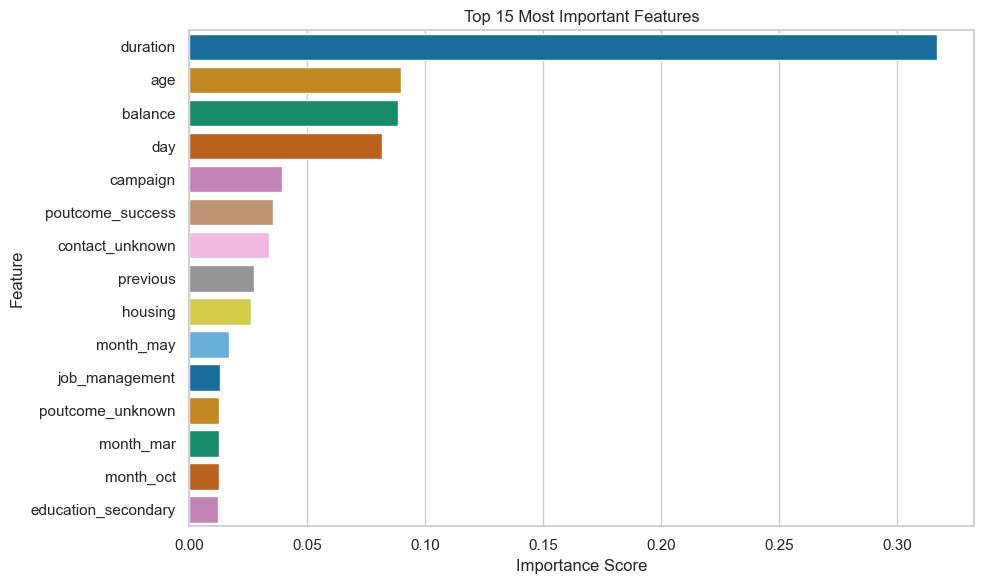

In [23]:
#Feature Importance via Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train a quick Random Forest to get feature importances
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Top 15 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[:15].values, y=importances[:15].index, palette='colorblind')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [24]:
# Select top 15 most important features for our model
top_features = importances[:15].index.tolist()

X = X[top_features]

print("Selected features:")
for i, f in enumerate(top_features, 1):
    print(f"  {i}. {f}")

print("\nFinal X shape:", X.shape)

Selected features:
  1. duration
  2. age
  3. balance
  4. day
  5. campaign
  6. poutcome_success
  7. contact_unknown
  8. previous
  9. housing
  10. month_may
  11. job_management
  12. poutcome_unknown
  13. month_mar
  14. month_oct
  15. education_secondary

Final X shape: (11720, 15)


Model Training 

In [25]:
#  Train / Test Split
from sklearn.model_selection import train_test_split

# Split data - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (9376, 15)
Testing set size: (2344, 15)


In [26]:
#Feature Scaling with StandardScaler
from sklearn.preprocessing import StandardScaler

# Scale features so all are on the same range
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done successfully!")

Scaling done successfully!


In [27]:
#Train and Evaluate Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Logistic Regression model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)

# Evaluation
print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print()
print(classification_report(y_test, lr_pred, target_names=['No', 'Yes']))

=== Logistic Regression ===
Accuracy: 79.31 %

              precision    recall  f1-score   support

          No       0.79      0.83      0.81      1233
         Yes       0.80      0.75      0.77      1111

    accuracy                           0.79      2344
   macro avg       0.79      0.79      0.79      2344
weighted avg       0.79      0.79      0.79      2344



In [28]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred) * 100, 2), "%")
print()
print(classification_report(y_test, rf_pred, target_names=['No', 'Yes']))

=== Random Forest ===
Accuracy: 83.28 %

              precision    recall  f1-score   support

          No       0.86      0.81      0.84      1233
         Yes       0.81      0.85      0.83      1111

    accuracy                           0.83      2344
   macro avg       0.83      0.83      0.83      2344
weighted avg       0.83      0.83      0.83      2344



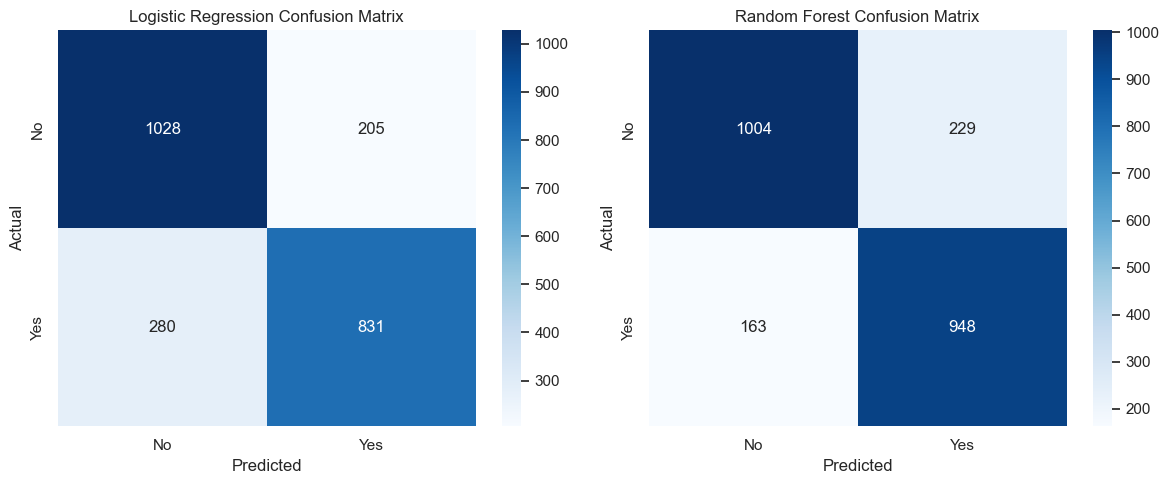

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, lr_pred), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], 
            yticklabels=['No', 'Yes'],
            ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_pred), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], 
            yticklabels=['No', 'Yes'],
            ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [30]:
# Summary comparison of both models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, lr_pred) * 100, 2),
        round(accuracy_score(y_test, rf_pred) * 100, 2)
    ]
})

print(results.to_string(index=False))

              Model  Accuracy
Logistic Regression     79.31
      Random Forest     83.28


Hyperparameter Tuning

In [31]:
from sklearn.model_selection import cross_val_score

# Check if our model is consistent across different data splits
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print("Cross Validation Scores:", cv_scores.round(4))
print("Mean Accuracy:", round(cv_scores.mean() * 100, 2), "%")
print("Standard Deviation:", round(cv_scores.std() * 100, 2), "%")

Cross Validation Scores: [0.8246 0.8235 0.8368 0.8283 0.8309]
Mean Accuracy: 82.88 %
Standard Deviation: 0.48 %


In [32]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid to search through
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Random search with 5-fold cross validation
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,               # Try 20 random combinations
    cv=5,                    # 5-fold cross validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest Parameters:", random_search.best_params_)
print("Best CV Accuracy:", round(random_search.best_score_ * 100, 2), "%")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV Accuracy: 83.06 %


In [33]:
# Use the best model found by Random Search
best_model = random_search.best_estimator_

# Predictions with tuned model
best_pred = best_model.predict(X_test)

print("=== Tuned Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, best_pred) * 100, 2), "%")
print()
print(classification_report(y_test, best_pred, target_names=['No', 'Yes']))

=== Tuned Random Forest ===
Accuracy: 82.85 %

              precision    recall  f1-score   support

          No       0.86      0.81      0.83      1233
         Yes       0.80      0.85      0.82      1111

    accuracy                           0.83      2344
   macro avg       0.83      0.83      0.83      2344
weighted avg       0.83      0.83      0.83      2344



In [34]:
# Compare all 3 models side by side
final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Tuned Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, lr_pred) * 100, 2),
        round(accuracy_score(y_test, rf_pred) * 100, 2),
        round(accuracy_score(y_test, best_pred) * 100, 2)
    ]
})

print(final_results.to_string(index=False))


              Model  Accuracy
Logistic Regression     79.31
      Random Forest     83.28
Tuned Random Forest     82.85


In [35]:
import joblib

# Save the BASE Random Forest since it performed better
joblib.dump(rf_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(top_features, 'top_features.pkl')

print("Best Model (Base Random Forest) saved as best_model.pkl")
print("Scaler saved as scaler.pkl")
print("Features saved as top_features.pkl")

Best Model (Base Random Forest) saved as best_model.pkl
Scaler saved as scaler.pkl
Features saved as top_features.pkl
